# 01 - Exploratory Data Analysis (EDA)

This notebook performs first-pass exploration of the Zillow house price prediction dataset.

In [3]:
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

current = Path.cwd().resolve()
project_root = None

for p in [current] + list(current.parents):
    if (p / "src" / "config.py").exists():
        project_root = p
        break

if project_root is None:
    raise FileNotFoundError("Could not find project root containing src/config.py")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import PROCESSED_DATA_PATH
from src.data.make_dataset import build_modeling_dataset


if PROCESSED_DATA_PATH.exists():
    df = pd.read_csv(PROCESSED_DATA_PATH)
    print("Loaded processed dataset.")
else:
    print("Processed dataset not found. Building it now...")
    df = build_modeling_dataset()

print("Shape:", df.shape)
df.head()

Loaded processed dataset.
Shape: (167888, 70)


,parcelid,logerror,transactiondate,data_year,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,...,censustractandblock,transaction_year,transaction_month,transaction_quarter,property_age,bath_bed_ratio,avg_room_size,structure_tax_ratio,land_tax_ratio,effective_tax_rate
0,11016594,0.0276,2016-01-01,2016,1.0,NaN,NaN,2.0,3.0,NaN,...,6.037107e+13,2016,1,1,57.0,0.666667,NaN,0.340822,0.659178,0.018702
1,14366692,-0.1684,2016-01-01,2016,NaN,NaN,NaN,3.5,4.0,NaN,...,NaN,2016,1,1,2.0,0.875000,NaN,0.591701,0.408299,0.017340
2,12098116,-0.0040,2016-01-01,2016,1.0,NaN,NaN,3.0,2.0,NaN,...,6.037464e+13,2016,1,1,76.0,1.500000,NaN,0.517022,0.482978,0.095779
3,12643413,0.0218,2016-01-02,2016,1.0,NaN,NaN,2.0,2.0,NaN,...,6.037296e+13,2016,1,1,29.0,1.000000,NaN,0.700417,0.299583,0.012450
4,14432541,-0.0050,2016-01-02,2016,NaN,NaN,NaN,2.5,4.0,NaN,...,6.059042e+13,2016,1,1,35.0,0.625000,285.375,0.390228,0.609772,0.012631


## Dataset overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167888 entries, 0 to 167887
Data columns (total 70 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   parcelid                      167888 non-null  int64  
 1   logerror                      167888 non-null  float64
 2   transactiondate               167888 non-null  object 
 3   data_year                     167888 non-null  int64  
 4   airconditioningtypeid         53788 non-null   float64
 5   architecturalstyletypeid      468 non-null     float64
 6   basementsqft                  93 non-null      float64
 7   bathroomcnt                   167854 non-null  float64
 8   bedroomcnt                    167854 non-null  float64
 9   buildingclasstypeid           31 non-null      float64
 10  buildingqualitytypeid         107173 non-null  float64
 11  calculatedbathnbr             166056 non-null  float64
 12  decktypeid                    1272 non-null 

In [5]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
parcelid,167888.0,NaN,NaN,NaN,12995358.543714,3016071.404728,10711738.0,11548985.75,12540601.0,14219303.0,167689317.0
logerror,167888.0,NaN,NaN,NaN,0.013906,0.165706,-4.65542,-0.0253,0.006,0.0392,5.262999
transactiondate,167888,616,2017-06-30,1195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
data_year,167888.0,NaN,NaN,NaN,2016.46229,0.498577,2016.0,2016.0,2016.0,2017.0,2017.0
airconditioningtypeid,53788.0,NaN,NaN,NaN,1.814345,2.970239,1.0,1.0,1.0,1.0,13.0
architecturalstyletypeid,468.0,NaN,NaN,NaN,7.299145,2.719633,2.0,7.0,7.0,7.0,21.0
basementsqft,93.0,NaN,NaN,NaN,695.376344,583.952144,38.0,280.0,588.0,819.0,3560.0
bathroomcnt,167854.0,NaN,NaN,NaN,2.288265,1.000835,0.0,2.0,2.0,3.0,20.0
bedroomcnt,167854.0,NaN,NaN,NaN,3.041739,1.149134,0.0,2.0,3.0,4.0,16.0
buildingclasstypeid,31.0,NaN,NaN,NaN,3.967742,0.179605,3.0,4.0,4.0,4.0,4.0


## Missing values

In [6]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing.head(30)

buildingclasstypeid         0.999815
finishedsquarefeet13        0.999553
storytypeid                 0.999446
basementsqft                0.999446
yardbuildingsqft26          0.999017
architecturalstyletypeid    0.997212
typeconstructiontypeid      0.996891
finishedsquarefeet6         0.995193
decktypeid                  0.992424
pooltypeid10                0.990315
poolsizesum                 0.989052
pooltypeid2                 0.986431
taxdelinquencyflag          0.972106
taxdelinquencyyear          0.972106
yardbuildingsqft17          0.969986
finishedsquarefeet15        0.960742
finishedfloor1squarefeet    0.923205
finishedsquarefeet50        0.923205
fireplacecnt                0.893405
threequarterbathnbr         0.868275
pooltypeid7                 0.810731
poolcnt                     0.797037
numberofstories             0.772652
avg_room_size               0.772616
airconditioningtypeid       0.679620
garagecarcnt                0.669679
garagetotalsqft             0.669679
r

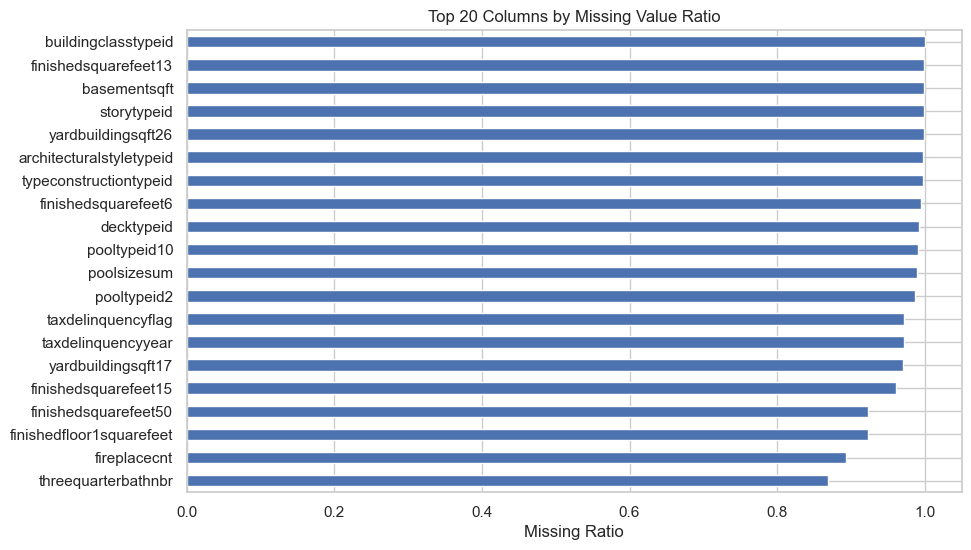

In [7]:
plt.figure(figsize=(10,6))
missing.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Columns by Missing Value Ratio")
plt.xlabel("Missing Ratio")
plt.show()

## Target overview

In [8]:
if "logerror" in df.columns:
    print(df["logerror"].describe())
else:
    print("Target column 'logerror' not found.")

count    167888.000000
mean          0.013906
std           0.165706
min          -4.655420
25%          -0.025300
50%           0.006000
75%           0.039200
max           5.262999
Name: logerror, dtype: float64


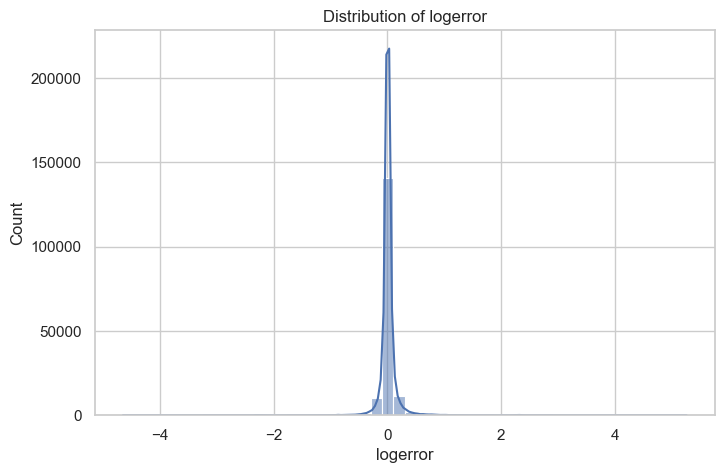

In [9]:
if "logerror" in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df["logerror"].dropna(), bins=50, kde=True)
    plt.title("Distribution of logerror")
    plt.show()

## Numerical and categorical split

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("\nSample numerical columns:", num_cols[:15])
print("\nSample categorical columns:", cat_cols[:15])

Numerical columns: 64
Categorical columns: 6

Sample numerical columns: ['parcelid', 'logerror', 'data_year', 'airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid', 'buildingqualitytypeid', 'calculatedbathnbr', 'decktypeid', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12']

Sample categorical columns: ['transactiondate', 'hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag']


## Duplicate check

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0
